In [1]:
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pdb
from IPython.display import display
import ee
import os

In [2]:
import ee
import geemap
service_account = ' boba-account@boba-430314.iam.gserviceaccount.com '
credentials = ee.ServiceAccountCredentials(service_account,'C:/Users/arj26323/OneDrive - University of Georgia/Documents/GEE AUTH/boba-430314-a19be859bfca.json')

ee.Initialize(credentials)

print(geemap.__version__)

0.34.1


In [3]:
import glob
import pandas as pd
##PC:
path = r'C:/Users/arj26323/Documents/Data/flats/Tide data' 
all_files = glob.glob(path + "/*.csv")

li = []

for filename in all_files:
    df = pd.read_csv(filename, index_col=None, header=0)
    li.append(df)

df_tides = pd.concat(li, axis=0, ignore_index=True)

df_tides

df2 = df_tides.copy()
df2['Time (GMT)'] = pd.to_datetime(df2['Time (GMT)'])
df2['DOY'] = pd.to_datetime(df2['Date'])

df_time = df2.copy()
df_time['Verified (m)'] = df_time['Verified (m)'].replace('-', float('nan')).astype('float')
df_time = df_time.dropna()
df_time['Tide change'] = df_time['Verified (m)'].diff()
df_time['Tide stage'] = df_time['Tide change'].apply(lambda x: 'Ebb' if x < 0 else 'Flood')

time_mask = (df_time['Time (GMT)'].dt.hour == 16)

df_time = df_time[time_mask]

df_time

C:\Users\arj26323\AppData\Local\Temp\ipykernel_19828\1512107381.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df2['Time (GMT)'] = pd.to_datetime(df2['Time (GMT)'])


,Date,Time (GMT),Predicted (m),Preliminary (m),Verified (m),DOY,Tide change,Tide stage
16,1985/01/02,2026-05-19 16:00:00,0.340,-,0.479,1985-01-02,0.018,Flood
40,1985/01/03,2026-05-19 16:00:00,0.275,-,0.406,1985-01-03,-0.159,Ebb
64,1985/01/04,2026-05-19 16:00:00,0.374,-,0.458,1985-01-04,-0.448,Ebb
88,1985/01/05,2026-05-19 16:00:00,0.620,-,0.543,1985-01-05,-0.363,Ebb
112,1985/01/06,2026-05-19 16:00:00,0.967,-,1.162,1985-01-06,-0.381,Ebb
...,...,...,...,...,...,...,...,...
350536,1984/12/28,2026-05-19 16:00:00,1.759,-,1.830,1984-12-28,0.412,Flood
350560,1984/12/29,2026-05-19 16:00:00,1.466,-,1.449,1984-12-29,0.345,Flood
350584,1984/12/30,2026-05-19 16:00:00,1.148,-,1.104,1984-12-30,0.317,Flood
350608,1984/12/31,2026-05-19 16:00:00,0.835,-,0.927,1984-12-31,0.329,Flood


In [52]:
# # ee.Initialize()

# Map = geemap.Map(center=[31.539096,-81.422318], zoom=10)

# bb = ee.Geometry.Polygon([[-81.29, 31.425], [-81.29, 31.46], [-81.27, 31.46],[-81.27, 31.425]])

juncus = ee.Geometry.Point([-81.6150, 30.8319]) ##Near cumberland, upriver. Shows lowest flats values for low tide, highest high

# juncus = ee.Geometry.Point([-81.3402, 31.3449]) ##Mouth of Altamaha 
##shows not much change in flats (stays low), even with tide change, indicating that a strong signal of water for detection!
##Supports your analysis

juncus = ee.Geometry.Point([-81.270, 31.4727]) ##Sapelo, near flux tower points, near tidal creek
##same thing - shows not much change in flats (stays low), even with tide change, need strong signal of water for detection!

# juncus = ee.Geometry.Point([-81.1919, 31.9060]) ##Farther north, in Georgia
##SAME THING! SEE HOW EVEN WITH MAX DETECTION, YOU NEED A STRONGER SIGNAL

# juncus = ee.Geometry.Point([-81.2650, 31.4043]) ##Sapelo, near oceanside creek by beach

tall_spartina = ee.Geometry.Point([-81.2855, 31.4461]) ##Flux tower points, lower elevation

short_spartina = ee.Geometry.Point([-81.2849, 31.4472]) #Flux tower, higher elevation
short_spartina = ee.Geometry.Point([-81.2843, 31.4474]) #Flux marsh, med elevation

bb = ee.Geometry.Polygon([juncus, tall_spartina, short_spartina])

In [53]:
##FLATS

#12/08/22 - add calibrated flats to images
def addFLATSL7(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(RED-SWIR)/(RED+SWIR) - 41.2*(NIR-RED)/(NIR+6*RED-7.5*BLUE+1)))', {
            'SWIR': image.select('SR_B5'),
            'NIR': image.select('SR_B4'),
            'RED': image.select('SR_B3'),
            'BLUE': image.select('SR_B1')
        })
    
    return image.addBands(flats.rename('flats'))

def addFLATSL5(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(0.972*(RED-SWIR)/(RED+SWIR)-0.008) - 41.2*(0.991*(NIR-RED)/(NIR+6*RED-7.5*BLUE+1)-0.0014)))', {
            'SWIR': image.select('SR_B5'),
            'NIR': image.select('SR_B4'),
            'RED': image.select('SR_B3'),
            'BLUE': image.select('SR_B1')
        })
    
    return image.addBands(flats.rename('flats'))


def addFLATSL8(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(0.841*(RED-SWIR)/(RED+SWIR) - 0.019) - 41.2*(0.771*(NIR-RED)/(NIR+6*RED-7.5*BLUE+1) + 0.011)))', {
            'SWIR': image.select('SR_B6'),
            'NIR': image.select('SR_B5'),
            'RED': image.select('SR_B4'),
            'BLUE': image.select('SR_B2')
        })
    
    return image.addBands(flats.rename('flats'))

def addFLATSL9(image):
    flats = ee.Image(0).expression(
        '1/(1+2.718281828459045**-(1.51 + 12.5*(1.225*(RED-SWIR)/(RED+SWIR) + 0.096) - 41.2*(1.038* (NIR-RED)/(NIR+6*RED-7.5*BLUE+1) - 0.004)))', {
            'SWIR': image.select('SR_B6'),
            'NIR': image.select('SR_B5'),
            'RED': image.select('SR_B4'),
            'BLUE': image.select('SR_B2')
        })
    
    return image.addBands(flats.rename('flats'))

In [54]:
# Function to add the date band
def add_date_band(image):
    # Get the acquisition date
    date = ee.Date(image.get('system:time_start'))
    
    # Convert the date to milliseconds since Unix epoch
    date_millis = date.millis()
    
    # Create an image with a single band representing the acquisition date
    date_image = ee.Image.constant(date_millis).int64().rename('acquisition_date')
    
    # Add the date image as a band to the original image
    return image.addBands(date_image)

In [55]:
##Function to cloud mask from the pixel_qa band of Landsat 5/8 SR data.
def maskL5sr(image):
    qaMask = image.select('QA_PIXEL').bitwiseAnd(int('11111', 2)).eq(0)
    saturationMask = image.select('QA_RADSAT').eq(0)
    # Apply the scaling factors to the appropriate bands.
    opticalBands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    thermalBands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
    # Replace the original bands with the scaled ones and apply the masks.
    return image.addBands(opticalBands, None, True) \
    .addBands(thermalBands, None, True) \
    .updateMask(qaMask) \
    .updateMask(saturationMask)

In [56]:
#Loading gee datasets
l8_col = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
    .filter(ee.Filter.calendarRange(1998, 2023,'year')) \
    .filterBounds(bb) \
    .map(maskL5sr).map(addFLATSL8).map(add_date_band) \
    .filter(ee.Filter.lte('CLOUD_COVER_LAND', 50))

l7_col = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
    .filter(ee.Filter.calendarRange(1984, 2023,'year')) \
    .filterBounds(bb)\
    .map(maskL5sr).map(addFLATSL7).map(add_date_band) \
    .filter(ee.Filter.lte('CLOUD_COVER_LAND', 50))

l5_col = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2') \
    .filter(ee.Filter.calendarRange(1984, 2023,'year')) \
    .filterBounds(bb)\
    .map(maskL5sr).map(addFLATSL5).map(add_date_band) \
    .filter(ee.Filter.lte('CLOUD_COVER_LAND', 50))

l9_col = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2") \
    .filter(ee.Filter.calendarRange(1998, 2023,'year')) \
    .filterBounds(bb)\
    .map(maskL5sr).map(addFLATSL9).map(add_date_band) \
    .filter(ee.Filter.lte('CLOUD_COVER_LAND', 50))

In [57]:
ultra_col = l8_col.merge(l5_col).merge(l7_col).merge(l9_col)

In [58]:
# Get the image IDs and acquisition dates separately
image_ids = ultra_col.aggregate_array('system:id').getInfo()
acquisition_dates = ultra_col.aggregate_array('system:time_start').getInfo()

# Create the DataFrame
dfx = pd.DataFrame({'Image': image_ids, 'acquisition_date': acquisition_dates})

dfx['Date'] = pd.to_datetime(dfx['acquisition_date'], unit='ms')
dfx['DOY'] = dfx['Date'].dt.strftime('%Y-%m-%d')
dfx['DOY'] = pd.to_datetime(dfx['DOY'])

df_u = pd.merge(dfx, df_time, on = 'DOY')

df_u['Verified (m)'] = df_u['Verified (m)'].replace('-', float('nan')).astype('float')

# Display the DataFrame
# print(dfx)
# print(df_u)

df_u['Verified (m)'] = df_u['Verified (m)'].replace('-', float('nan')).astype('float')

df_low = df_u[df_u['Verified (m)'] <= 0.8]
df_mid = df_u[df_u['Verified (m)'].between(0.8, 1.8)]
df_high = df_u[df_u['Verified (m)'] >= 1.8]

# print(df_low)

In [59]:
# points = ee.FeatureCollection([
#     ee.Feature(juncus, {'label': 'j'}),
#     ee.Feature(short_spartina, {'label': 'ss'}),
#     ee.Feature(tall_spartina, {'label': 'ts'})
# ])

##Buffering 45m out

distance = 45

points = ee.FeatureCollection([
    ee.Feature(juncus.buffer(distance), {'label': 'j'}),
    ee.Feature(short_spartina.buffer(distance), {'label': 'ss'}),
    ee.Feature(tall_spartina.buffer(distance), {'label': 'ts'})
])

In [60]:
# Create a list of image names
low_names = df_low['Image'].tolist()
mid_names = df_mid['Image'].tolist()
high_names = df_high['Image'].tolist()

# Initialize separate lists
LT05_list = []
LE07_list = []
LC09_list = []
LC08_list = []
other_list = []

# Iterate through the satellite names and separate them based on keys
names = low_names

for name in names:
    if 'LT05' in name:
        LT05_list.append(name)
    elif 'LE07' in name:
        LE07_list.append(name)
    elif 'LC09' in name:
        LC09_list.append(name)
    elif 'LC08' in name:
        LC08_list.append(name)
    else:
        other_list.append(name)

col5 = ee.ImageCollection(LT05_list).map(maskL5sr).map(addFLATSL5)
col7 = ee.ImageCollection(LE07_list).map(maskL5sr).map(addFLATSL7)
col8 = ee.ImageCollection(LC08_list).map(maskL5sr).map(addFLATSL8)
col9 = ee.ImageCollection(LC09_list).map(maskL5sr).map(addFLATSL9)

col = col5.merge(col7).merge(col8).merge(col9)

def get_data_via_getinfo(collection):
    mean_img = collection.select('flats').mean()
    
    # Chain the reducers together
    combined_reducer = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), sharedInputs=True) \
        .combine(ee.Reducer.min(), sharedInputs=True) \
        .combine(ee.Reducer.max(), sharedInputs=True)
    
    fc = mean_img.reduceRegions(
        collection=points, 
        reducer=combined_reducer,
        scale=30
    )
    
    raw_dict = fc.getInfo()
    features = [f['properties'] for f in raw_dict['features']]
    df = pd.DataFrame(features)
    return df

# # 2. Define a function to extract values using your points
# def get_data_via_getinfo(collection):
#     # Reduce collection to mean and select Band 5
#     mean_img = collection.select('flats').mean()
    
#     # Extract values at points
#     fc = mean_img.reduceRegions(
#         collection=points, # Your ee.FeatureCollection of a, b, and c
#         reducer=ee.Reducer.first(),
#         scale=30
#     )
    
#     # The 'No-Geemap' way to get the data into Pandas
#     raw_dict = fc.getInfo()
#     features = [f['properties'] for f in raw_dict['features']]
#     df = pd.DataFrame(features)
#     return df

# 3. Run for all three and combine
low_results = get_data_via_getinfo(col)
low_results['tide'] = 'low'

print('low:')
print(low_results)

low:
  label       max      mean       min    stdDev tide
0     j  0.110609  0.013885  0.007749  0.024400  low
1    ss  0.207118  0.141639  0.040337  0.049877  low
2    ts  0.990354  0.294414  0.010548  0.397888  low


In [61]:
names = mid_names

for name in names:
    if 'LT05' in name:
        LT05_list.append(name)
    elif 'LE07' in name:
        LE07_list.append(name)
    elif 'LC09' in name:
        LC09_list.append(name)
    elif 'LC08' in name:
        LC08_list.append(name)
    else:
        other_list.append(name)

col5 = ee.ImageCollection(LT05_list).map(maskL5sr).map(addFLATSL5)
col7 = ee.ImageCollection(LE07_list).map(maskL5sr).map(addFLATSL7)
col8 = ee.ImageCollection(LC08_list).map(maskL5sr).map(addFLATSL8)
col9 = ee.ImageCollection(LC09_list).map(maskL5sr).map(addFLATSL9)

col = col5.merge(col7).merge(col8).merge(col9)


# 2. Define a function to extract values using your points
def get_data_via_getinfo(collection):
    mean_img = collection.select('flats').mean()
    
    # Chain the reducers together
    combined_reducer = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), sharedInputs=True) \
        .combine(ee.Reducer.min(), sharedInputs=True) \
        .combine(ee.Reducer.max(), sharedInputs=True)
    
    fc = mean_img.reduceRegions(
        collection=points, 
        reducer=combined_reducer,
        scale=30
    )
    
    raw_dict = fc.getInfo()
    features = [f['properties'] for f in raw_dict['features']]
    df = pd.DataFrame(features)
    return df

# 3. Run for all three and combine
mid_results = get_data_via_getinfo(col)
mid_results['tide'] = 'mid'


print('mid:')
print(mid_results)

mid:
  label       max      mean       min    stdDev tide
0     j  0.108921  0.015955  0.008474  0.023774  mid
1    ss  0.270677  0.193020  0.067250  0.059510  mid
2    ts  0.990888  0.316270  0.017746  0.395978  mid


In [62]:
names = high_names

for name in names:
    if 'LT05' in name:
        LT05_list.append(name)
    elif 'LE07' in name:
        LE07_list.append(name)
    elif 'LC09' in name:
        LC09_list.append(name)
    elif 'LC08' in name:
        LC08_list.append(name)
    else:
        other_list.append(name)

col5 = ee.ImageCollection(LT05_list).map(maskL5sr).map(addFLATSL5)
col7 = ee.ImageCollection(LE07_list).map(maskL5sr).map(addFLATSL7)
col8 = ee.ImageCollection(LC08_list).map(maskL5sr).map(addFLATSL8)
col9 = ee.ImageCollection(LC09_list).map(maskL5sr).map(addFLATSL9)

col = col5.merge(col7).merge(col8).merge(col9)


# 2. Define a function to extract values using your points
def get_data_via_getinfo(collection):
    mean_img = collection.select('flats').mean()
    
    # Chain the reducers together
    combined_reducer = ee.Reducer.mean() \
        .combine(ee.Reducer.stdDev(), sharedInputs=True) \
        .combine(ee.Reducer.min(), sharedInputs=True) \
        .combine(ee.Reducer.max(), sharedInputs=True)
    
    fc = mean_img.reduceRegions(
        collection=points, 
        reducer=combined_reducer,
        scale=30
    )
    
    raw_dict = fc.getInfo()
    features = [f['properties'] for f in raw_dict['features']]
    df = pd.DataFrame(features)
    return df

# 3. Run for all three and combine
high_results = get_data_via_getinfo(col)
high_results['tide'] = 'high'

print('high:')
print(high_results)

high:
  label       max      mean       min    stdDev  tide
0     j  0.114315  0.020315  0.009427  0.028176  high
1    ss  0.342936  0.264695  0.119382  0.063696  high
2    ts  0.990566  0.349428  0.030937  0.386875  high


In [63]:
print('low count: ' + str(len(low_names)))
print('mid count: ' + str(len(mid_names)))
print('high count: ' + str(len(high_names)))

low count: 555
mid count: 613
high count: 499


In [64]:
dfx = pd.concat([low_results, mid_results, high_results])
dfx

,label,max,mean,min,stdDev,tide
0,j,0.110609,0.013885,0.007749,0.024400,low
1,ss,0.207118,0.141639,0.040337,0.049877,low
2,ts,0.990354,0.294414,0.010548,0.397888,low
0,j,0.108921,0.015955,0.008474,0.023774,mid
1,ss,0.270677,0.193020,0.067250,0.059510,mid
2,ts,0.990888,0.316270,0.017746,0.395978,mid
0,j,0.114315,0.020315,0.009427,0.028176,high
1,ss,0.342936,0.264695,0.119382,0.063696,high
2,ts,0.990566,0.349428,0.030937,0.386875,high


C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

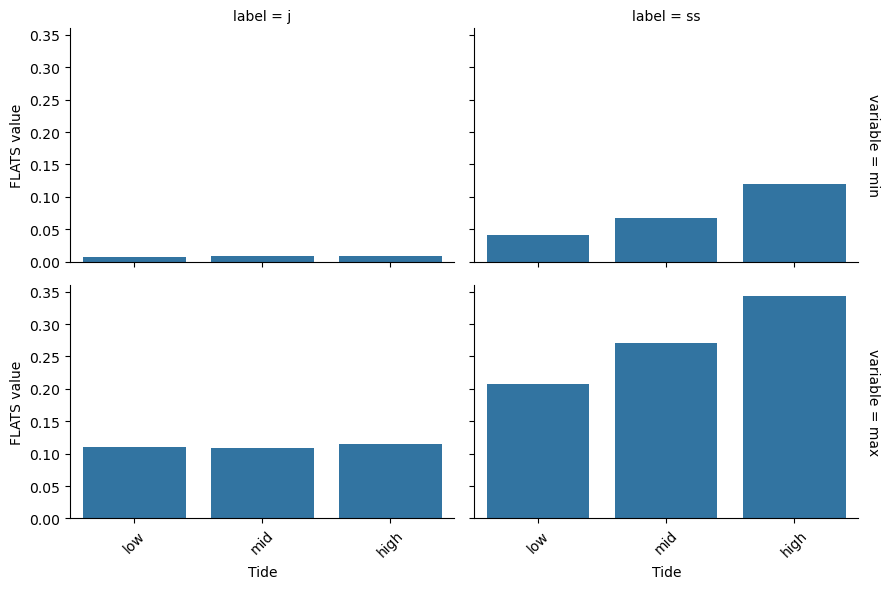

In [65]:
import seaborn as sns

dfx = pd.concat([low_results, mid_results, high_results])

dfx = dfx[dfx['label'] != 'ts']

long_df = dfx.melt(
    id_vars=['label', 'tide'],
    value_vars=[
        'min',
        'max'
    ],
    var_name='variable',
    value_name='value'
)

g = sns.FacetGrid(
    long_df,
    row='variable',          # one row per site
    col='label',      # one column per variable
    margin_titles=True,
    sharey=True,
    height=3,
    aspect=1.5
)

g.map_dataframe(
    sns.barplot,
    x='tide',
    y='value'
)

g.set_axis_labels("Tide", "FLATS value")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\arj26323\.conda\envs\geeml\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

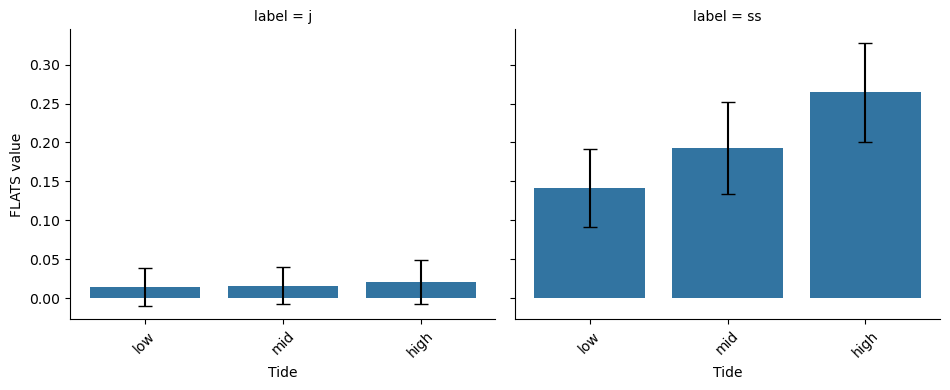

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Melt ONLY the 'mean' column to build the bars, 
# but keep 'stdDev' as a column side-by-side with it!
long_df = dfx.melt(
    id_vars=['label', 'tide', 'stdDev'],  # Keep stdDev here
    value_vars=['mean'],                  # Only melt the mean
    var_name='variable',
    value_name='mean_value'
)

# 2. Define a custom function to handle the bars + error bars per facet
def custom_error_bars(data, **kwargs):
    # Draw the standard barplot for the mean
    ax = sns.barplot(data=data, x='tide', y='mean_value', **kwargs)
    
    # Grab the x coordinates of the generated bars
    x_coords = [p.get_x() + p.get_width() / 2 for p in ax.patches]
    
    # Extract the matching mean and stdDev values in the correct order
    y_coords = data.groupby('tide')['mean_value'].first().reindex(data['tide'].unique()).values
    y_errors = data.groupby('tide')['stdDev'].first().reindex(data['tide'].unique()).values
    
    # Overlay the error bars manually using matplotlib
    ax.errorbar(
        x=x_coords[:len(y_coords)], 
        y=y_coords, 
        yerr=y_errors, 
        fmt='none',       # 'none' keeps it from drawing line markers over the bars
        color='black',    # Color of the error bar
        capsize=5,        # Adds horizontal caps to the top/bottom of the error bar
        zorder=3          # Forces error bars to sit neatly on top of the bars
    )

# 3. Setup the FacetGrid
g = sns.FacetGrid(
    long_df,
    col='label',          # One column per site
    margin_titles=True,
    sharey=True,          # Locks the y-axis scales together
    height=4,
    aspect=1.2
)

# 4. Map our custom function to the grid instead of standard sns.barplot
g.map_dataframe(custom_error_bars)

g.set_axis_labels("Tide", "FLATS value")

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [32]:
#Fin
